# Sales Trends & Seasonality
Goal: investigate seasonality and long-term trends in sales.

Data: `cleaned_train` + `cleaned_store` (2013-01-01 to 2015-07-31). Main metric: **average sales per open store-day**, because total sales depend on how many stores report and are open (see section 1). Closed days (`Open = 0`) are excluded.

In [1]:
import calendar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, GREY, ORANGE, RED = '#2f80ed', '#9aa5b1', '#f2994a', '#d64545'

# Colab: files next to the notebook. Repo: ../dataset/cleaned
DATA = Path('.') if Path('cleaned_store.csv').exists() else Path('../dataset/cleaned')
train_path = next(p for p in [DATA/'cleaned_train.csv', DATA/'cleaned_train.zip'] if p.exists())

train = pd.read_csv(train_path, dtype={'StateHoliday': str}, parse_dates=['Date'])
store = pd.read_csv(DATA/'cleaned_store.csv')
df = train.merge(store, on='Store', how='left')

o = df[df['Open'] == 1].copy()
o['Year'], o['Month'], o['DayOfMonth'] = o['Date'].dt.year, o['Date'].dt.month, o['Date'].dt.day
o['Season'] = o['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
                              6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})
o['Quarter'] = o['Date'].dt.quarter
o['MonthPeriod'] = pd.cut(o['DayOfMonth'], [0, 10, 20, 31], labels=['Days 1-10', 'Days 11-20', 'Days 21-end'])

# one row per day, plus a flag for "normal" days (holidays/Sundays have very few open stores)
daily = o.groupby('Date').agg(avg=('Sales', 'mean'), total=('Sales', 'sum'), open_stores=('Store', 'count'), promo=('Promo', 'mean'))
daily['normal'] = daily['open_stores'] >= 800
print(f'Open store-days: {len(o):,} | days: {len(daily)} | normal days: {daily.normal.sum()}')

Open store-days: 844,338 | days: 942 | normal days: 778


## 1. Data coverage
Not every store reports every day. Check how many stores appear per month before comparing totals.

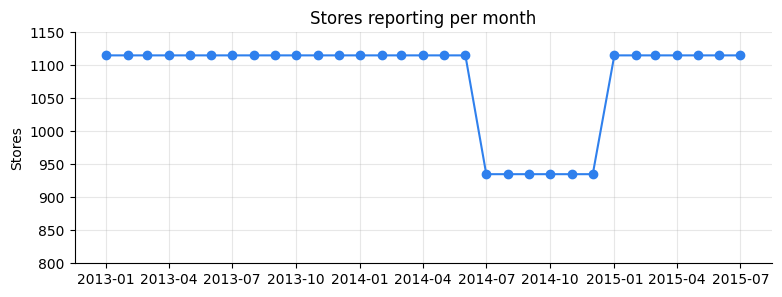

2014-07 -> 2014-12: only ~935 of 1115 stores report


In [2]:
stores_reporting = df.groupby(pd.Grouper(key='Date', freq='MS'))['Store'].nunique()
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(stores_reporting.index, stores_reporting.values, marker='o', color=BLUE)
ax.set(title='Stores reporting per month', ylabel='Stores', ylim=(800, 1150))
plt.show()
gap = stores_reporting[stores_reporting < 1100]
print(f'{gap.index.min():%Y-%m} -> {gap.index.max():%Y-%m}: only ~{int(gap.median())} of 1115 stores report')

About 180 stores are missing from July to December 2014. Totals in that period are lower for this reason, so trends below use the per-store-day average.

## 2. Monthly sales trend

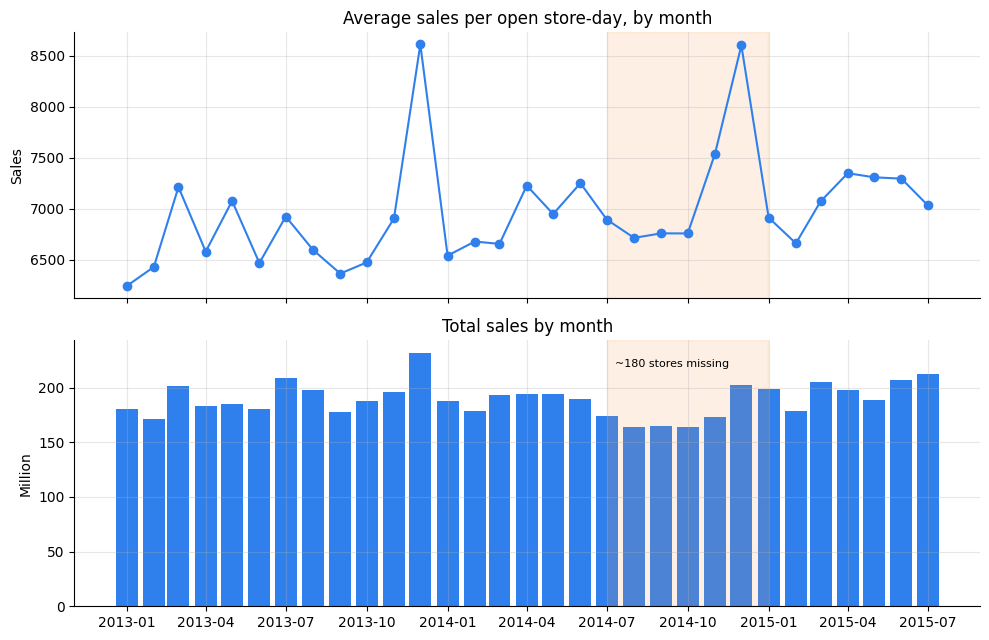

In [3]:
monthly = o.groupby(pd.Grouper(key='Date', freq='MS')).agg(avg=('Sales', 'mean'), total=('Sales', 'sum'), promo=('Promo', 'mean'))

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(monthly.index, monthly['avg'], marker='o', color=BLUE)
axes[0].set(title='Average sales per open store-day, by month', ylabel='Sales')
axes[1].bar(monthly.index, monthly['total'] / 1e6, width=25, color=BLUE)
axes[1].set(title='Total sales by month', ylabel='Million')
for a in axes:
    a.axvspan(pd.Timestamp('2014-07-01'), pd.Timestamp('2014-12-31'), color=ORANGE, alpha=0.15)
axes[1].text(pd.Timestamp('2014-07-10'), axes[1].get_ylim()[1] * 0.9, '~180 stores missing', fontsize=8)
plt.tight_layout(); plt.show()

## 3. Sales trend over time

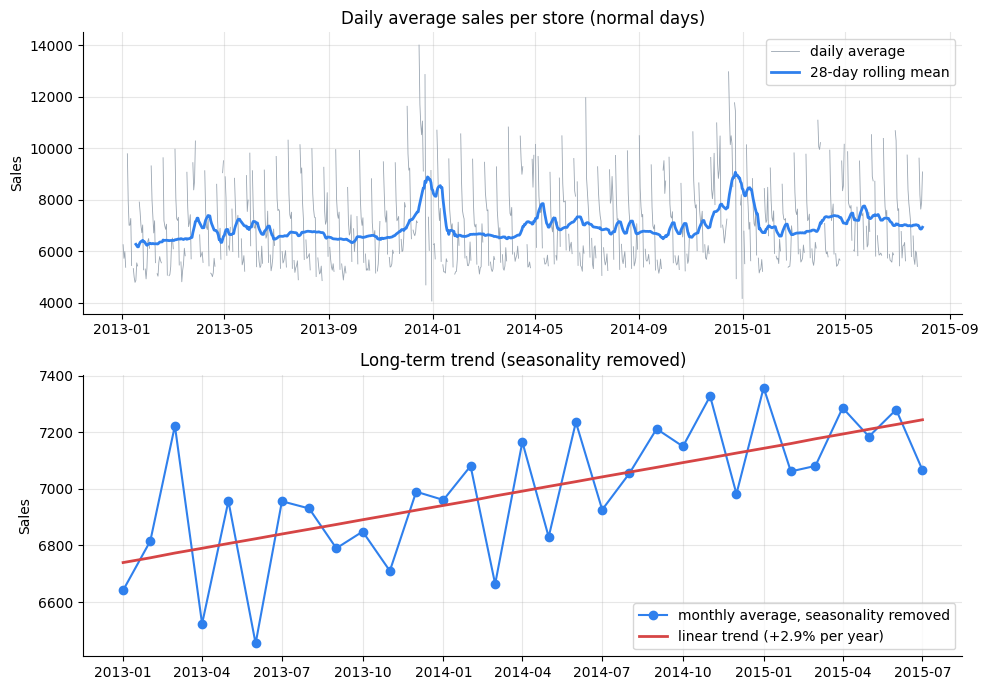

Estimated long-term growth: +2.9% per year (based on only ~2.5 years of data)


In [4]:
s = daily['avg'].where(daily['normal'])
roll = s.rolling(28, min_periods=14).mean()

seas = o.groupby('Month')['Sales'].mean()
seas_idx = seas / seas.mean()                                   # seasonal index per calendar month
monthly['deseason'] = monthly['avg'] / monthly.index.month.map(seas_idx).values
x = np.arange(len(monthly))
slope, icpt = np.polyfit(x, monthly['deseason'], 1)
annual_growth = slope * 12 / monthly['deseason'].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
axes[0].plot(s.index, s, color=GREY, lw=0.6, label='daily average')
axes[0].plot(roll.index, roll, color=BLUE, lw=2, label='28-day rolling mean')
axes[0].set(title='Daily average sales per store (normal days)', ylabel='Sales'); axes[0].legend()
axes[1].plot(monthly.index, monthly['deseason'], marker='o', color=BLUE, label='monthly average, seasonality removed')
axes[1].plot(monthly.index, icpt + slope * x, color=RED, lw=2, label=f'linear trend ({annual_growth:+.1%} per year)')
axes[1].set(title='Long-term trend (seasonality removed)', ylabel='Sales'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Estimated long-term growth: {annual_growth:+.1%} per year (based on only ~2.5 years of data)')

## 4. Yearly sales trend

,total,avg
Year,,
2013,2302876084,6815.0
2014,2180804896,7026.0
2015 (Jan-Jul only),1389499643,7088.0


,total,avg,avg_growth_%,total_growth_%
Year,,,,
2013,1311235579,6703.0,NaN,NaN
2014,1312875310,6878.2,2.6,0.1
2015,1389499643,7088.2,3.1,5.8


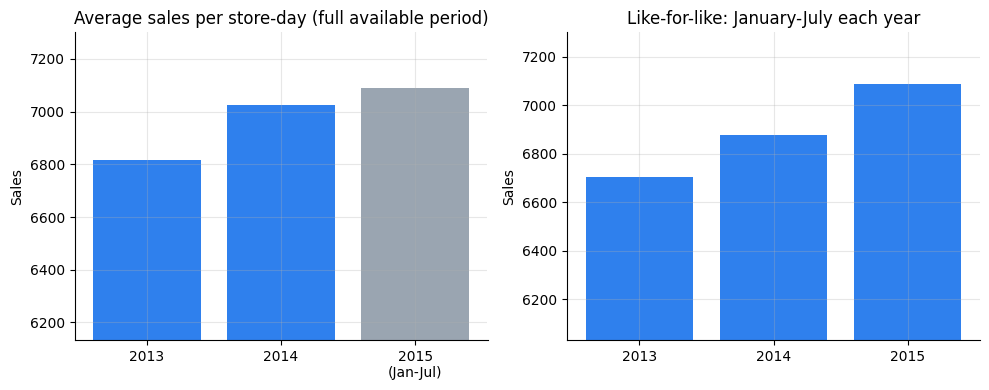

In [5]:
yearly = o.groupby('Year').agg(total=('Sales', 'sum'), avg=('Sales', 'mean'))
lfl = o[o['Month'] <= 7].groupby('Year').agg(total=('Sales', 'sum'), avg=('Sales', 'mean'))   # Jan-Jul only, comparable across years
lfl['avg_growth_%'] = (lfl['avg'].pct_change() * 100).round(1)
lfl['total_growth_%'] = (lfl['total'].pct_change() * 100).round(1)
display(yearly.round(0).rename(index={2015: '2015 (Jan-Jul only)'}))
display(lfl.round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['2013', '2014', '2015\n(Jan-Jul)'], yearly['avg'], color=[BLUE, BLUE, GREY]); axes[0].set(title='Average sales per store-day (full available period)', ylabel='Sales')
axes[1].bar(lfl.index.astype(str), lfl['avg'], color=BLUE); axes[1].set(title='Like-for-like: January-July each year', ylabel='Sales')
for a, vals in zip(axes, [yearly['avg'], lfl['avg']]):
    a.set_ylim(vals.min() * 0.9, vals.max() * 1.03)
plt.tight_layout(); plt.show()

2015 only covers January-July, so full-year totals are not comparable. The January-July comparison is the fair one.

## 5. Sales by day of week

,count,mean,median,std
DayOfWeek,,,,
Mon,137557,8216.3,7539.0,3691.6
Tue,143955,7088.4,6502.0,3066.0
Wed,141922,6728.8,6210.0,2781.1
Thu,134626,6768.2,6246.0,2763.6
Fri,138633,7073.0,6581.0,2764.5
Sat,144052,5875.1,5425.0,2852.5
Sun,3593,8224.7,6876.0,6235.2


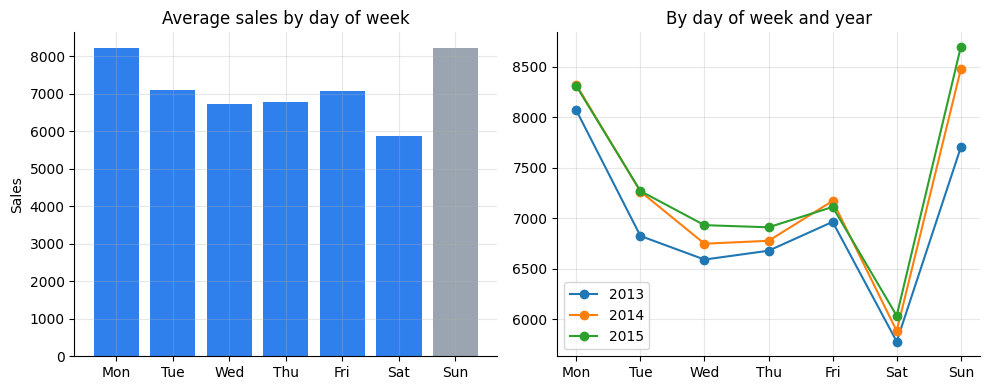

In [6]:
dow_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow = o.groupby('DayOfWeek')['Sales'].agg(['count', 'mean', 'median', 'std']).round(1)
dow.index = dow.index.map(dow_names)
display(dow)
dow_year = o.groupby(['Year', 'DayOfWeek'])['Sales'].mean().unstack(0)
dow_year.index = dow_year.index.map(dow_names)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(dow.index, dow['mean'], color=[BLUE] * 6 + [GREY]); axes[0].set(title='Average sales by day of week', ylabel='Sales')
for y in dow_year.columns:
    axes[1].plot(dow_year.index, dow_year[y], marker='o', label=str(y))
axes[1].set(title='By day of week and year'); axes[1].legend()
plt.tight_layout(); plt.show()

Sunday (grey) is based on only ~2.5% of store-days, a small and unusual group of stores.

## 6. Sales by month

,mean,median,std,seasonal_index
Jan,6564.0,6062.0,2849.0,0.940
Feb,6589.0,6079.0,2871.0,0.943
Mar,6977.0,6385.0,3124.0,0.999
Apr,7047.0,6431.0,3138.0,1.009
May,7107.0,6592.0,3008.0,1.017
Jun,7001.0,6365.0,3145.0,1.002
Jul,6954.0,6407.0,3003.0,0.995
Aug,6649.0,6124.0,2902.0,0.952
Sep,6547.0,6000.0,2889.0,0.937
Oct,6603.0,6105.0,2815.0,0.945


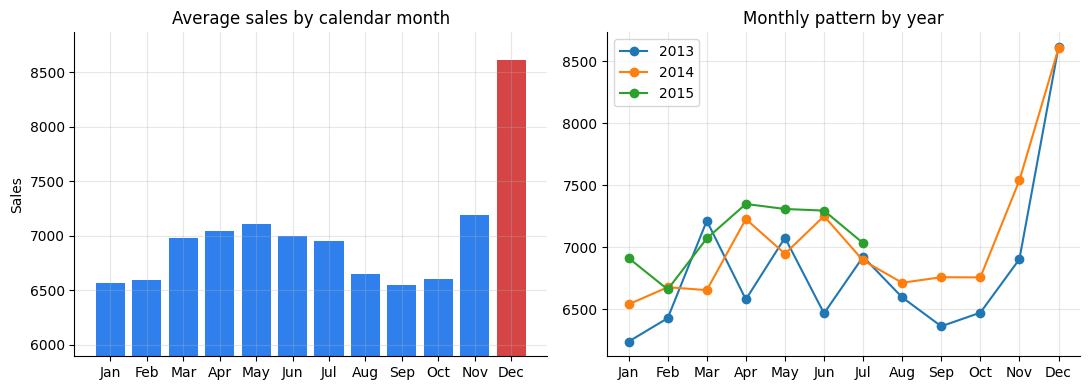

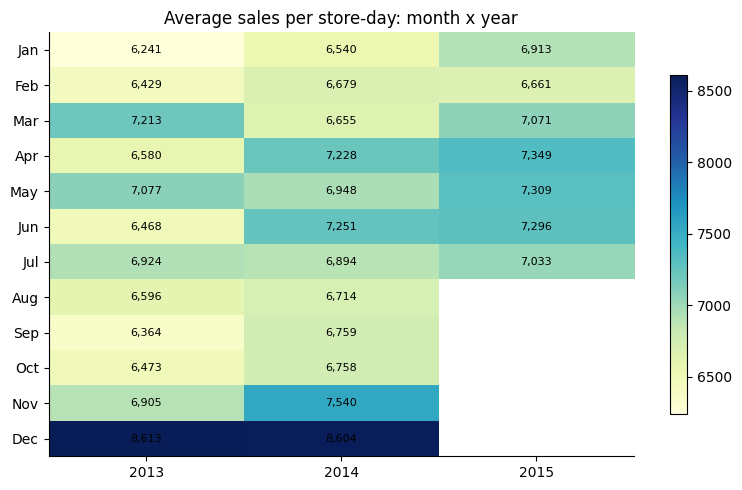

In [7]:
month_tbl = o.groupby('Month')['Sales'].agg(['mean', 'median', 'std']).round(0)
month_tbl['seasonal_index'] = seas_idx.round(3)
month_tbl.index = [calendar.month_abbr[m] for m in month_tbl.index]
display(month_tbl)

pivot = monthly.assign(Year=monthly.index.year, Month=monthly.index.month).pivot(index='Month', columns='Year', values='avg')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = [RED if m == seas.idxmax() else BLUE for m in seas.index]
axes[0].bar(month_tbl.index, seas.values, color=colors); axes[0].set(title='Average sales by calendar month', ylabel='Sales')
axes[0].set_ylim(seas.min() * 0.9, seas.max() * 1.03)
for y in pivot.columns:
    axes[1].plot([calendar.month_abbr[m] for m in pivot.index], pivot[y], marker='o', label=str(y))
axes[1].set(title='Monthly pattern by year'); axes[1].legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)), pivot.columns); ax.set_yticks(range(12), [calendar.month_abbr[m] for m in pivot.index])
for i in range(12):
    for j in range(len(pivot.columns)):
        if not np.isnan(pivot.values[i, j]):
            ax.text(j, i, f'{pivot.values[i, j]:,.0f}', ha='center', va='center', fontsize=8)
ax.grid(False); ax.set_title('Average sales per store-day: month x year'); fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

## 7. Sales by season / time period

,mean,median,std
Season,,,
Winter,7049.0,6383.0,3303.0
Spring,7042.0,6470.0,3092.0
Summer,6897.0,6324.0,3036.0
Autumn,6776.0,6256.0,2919.0


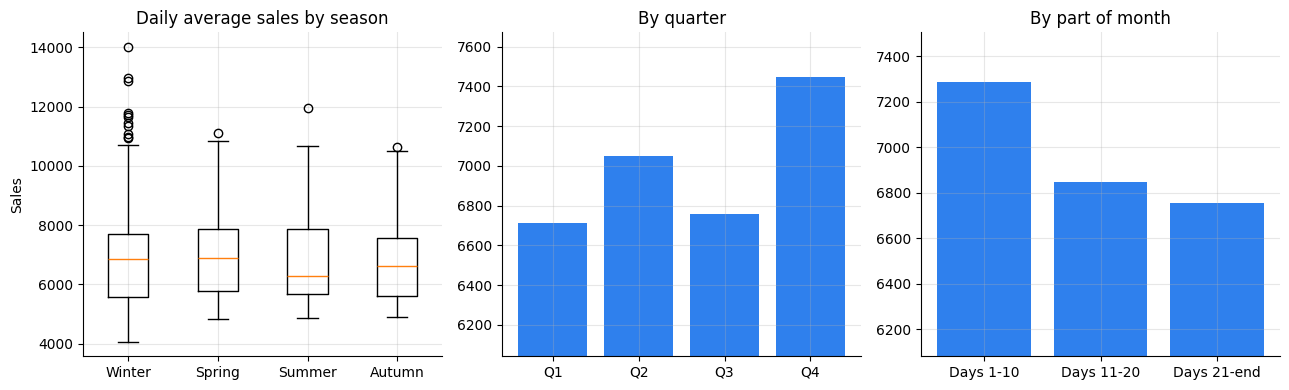

In [8]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
d = daily[daily['normal']].copy()
d['Season'] = d.index.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})
season_tbl = o.groupby('Season')['Sales'].agg(['mean', 'median', 'std']).loc[season_order].round(0)
quarter_tbl = o.groupby('Quarter')['Sales'].mean().round(0)
period_tbl = o.groupby('MonthPeriod', observed=True)['Sales'].mean().round(0)
display(season_tbl)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].boxplot([d.loc[d.Season == s, 'avg'] for s in season_order], tick_labels=season_order)
axes[0].set(title='Daily average sales by season', ylabel='Sales')
axes[1].bar([f'Q{q}' for q in quarter_tbl.index], quarter_tbl.values, color=BLUE); axes[1].set(title='By quarter')
axes[2].bar(period_tbl.index.astype(str), period_tbl.values, color=BLUE); axes[2].set(title='By part of month')
for a, v in zip(axes[1:], [quarter_tbl, period_tbl]):
    a.set_ylim(v.min() * 0.9, v.max() * 1.03)
plt.tight_layout(); plt.show()

## 8. Peak and low-sales periods

In [9]:
ranked = monthly['avg'].sort_values()
low_months = ranked.head(5).round(0).rename(lambda t: f'{t:%Y-%m}')
peak_months = ranked.tail(5)[::-1].round(0).rename(lambda t: f'{t:%Y-%m}')
nd = daily[daily['normal']]['avg']
peak_days = nd.nlargest(5).round(0).rename(lambda t: f'{t:%Y-%m-%d (%a)}')
low_days = nd.nsmallest(5).round(0).rename(lambda t: f'{t:%Y-%m-%d (%a)}')
display(pd.DataFrame({'peak months': peak_months.reset_index(drop=True).astype(str) + ' | ' + peak_months.index,
                      'low months': low_months.reset_index(drop=True).astype(str) + ' | ' + low_months.index}))
display(pd.DataFrame({'peak days': peak_days.reset_index(drop=True).astype(str) + ' | ' + peak_days.index,
                      'low days': low_days.reset_index(drop=True).astype(str) + ' | ' + low_days.index}))

,peak months,low months
0,8613.0 | 2013-12,6241.0 | 2013-01
1,8604.0 | 2014-12,6364.0 | 2013-09
2,7540.0 | 2014-11,6429.0 | 2013-02
3,7349.0 | 2015-04,6468.0 | 2013-06
4,7309.0 | 2015-05,6473.0 | 2013-10


,peak days,low days
0,14012.0 | 2013-12-16 (Mon),4067.0 | 2013-12-31 (Tue)
1,12977.0 | 2014-12-15 (Mon),4166.0 | 2014-12-31 (Wed)
2,12870.0 | 2013-12-23 (Mon),4693.0 | 2013-12-24 (Tue)
3,11968.0 | 2014-06-30 (Mon),4790.0 | 2013-01-16 (Wed)
4,11773.0 | 2014-12-22 (Mon),4814.0 | 2013-03-12 (Tue)


## 9. Promotional patterns over time

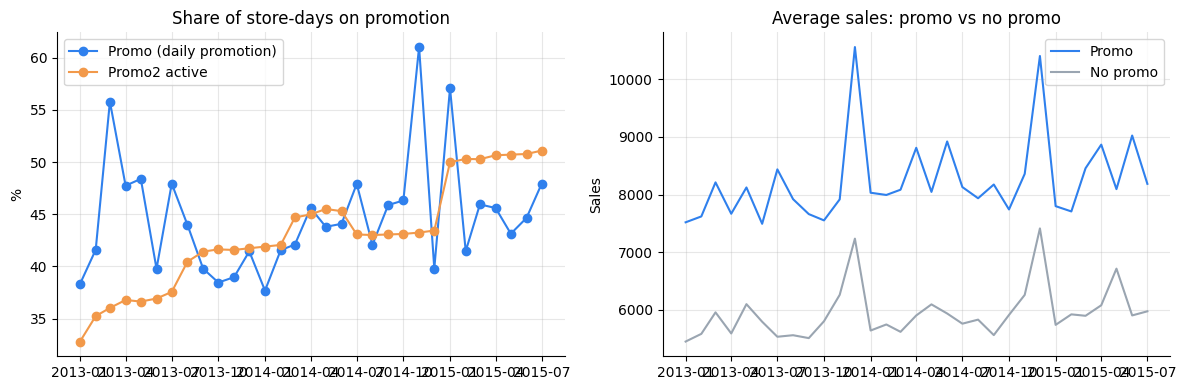

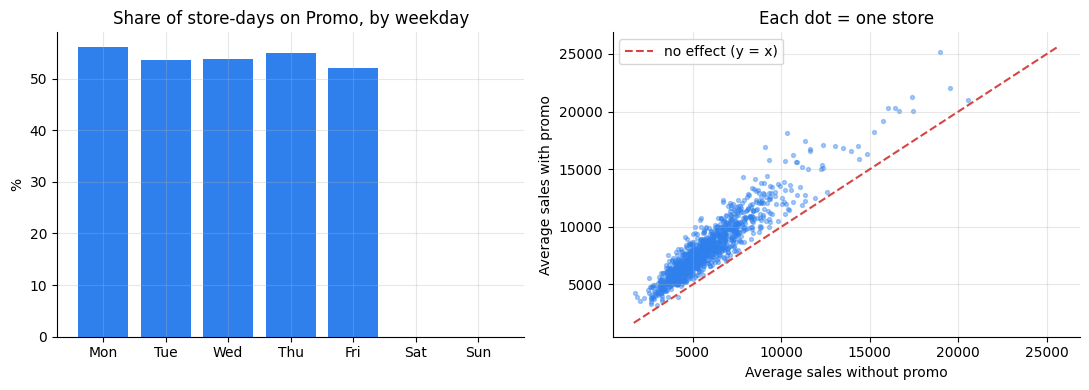

Year
2013    0.435
2014    0.446
2015    0.467
Name: promo share, dtype: float64

In [10]:
# Promo2 (continuous promotion) is active from its start week onwards
start = {r.Store: pd.Timestamp.fromisocalendar(int(r.Promo2SinceYear), int(r.Promo2SinceWeek), 1)
         for r in store.itertuples() if r.Promo2 == 1 and r.Promo2SinceYear > 0}
o['Promo2Start'] = o['Store'].map(start)
o['Promo2Active'] = (o['Date'] >= o['Promo2Start']).astype(int)

promo_m = o.groupby(pd.Grouper(key='Date', freq='MS')).agg(promo=('Promo', 'mean'), promo2=('Promo2Active', 'mean'))
sales_pm = o.groupby([pd.Grouper(key='Date', freq='MS'), 'Promo'])['Sales'].mean().unstack()
promo_dow = o.groupby('DayOfWeek')['Promo'].mean()
promo_year = o.groupby('Year')['Promo'].mean().round(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(promo_m.index, promo_m['promo'] * 100, marker='o', color=BLUE, label='Promo (daily promotion)')
axes[0].plot(promo_m.index, promo_m['promo2'] * 100, marker='o', color=ORANGE, label='Promo2 active')
axes[0].set(title='Share of store-days on promotion', ylabel='%'); axes[0].legend()
axes[1].plot(sales_pm.index, sales_pm[1], color=BLUE, label='Promo'); axes[1].plot(sales_pm.index, sales_pm[0], color=GREY, label='No promo')
axes[1].set(title='Average sales: promo vs no promo', ylabel='Sales'); axes[1].legend()
plt.tight_layout(); plt.show()

wk = daily[daily.index.dayofweek < 5]
promo_day_share = (wk['promo'] > 0.5).mean()          # promo is chain-wide: a day is either on or off
ps = o.groupby(['Store', 'Promo'])['Sales'].mean().unstack().dropna()
above = (ps[1] > ps[0]).mean()
lim = [ps.min().min() * 0.95, ps.max().max() * 1.02]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar([dow_names[i] for i in promo_dow.index], promo_dow.values * 100, color=BLUE); axes[0].set(title='Share of store-days on Promo, by weekday', ylabel='%')
axes[1].scatter(ps[0], ps[1], s=8, alpha=0.4, color=BLUE)
axes[1].plot(lim, lim, color=RED, ls='--', label='no effect (y = x)')
axes[1].set(title='Each dot = one store', xlabel='Average sales without promo', ylabel='Average sales with promo'); axes[1].legend()
plt.tight_layout(); plt.show()
display(promo_year.rename('promo share'))

## 10. Key findings

In [11]:
mon = lambda m: calendar.month_abbr[m]
best_m = seas.idxmax(); second_m = seas.drop(best_m).idxmax()
low1, low2 = seas.nsmallest(2).index
dow_reg = dow.drop('Sun')
g14 = lfl.loc[2014, 'avg_growth_%']; g15 = lfl.loc[2015, 'avg_growth_%']
winter_no_dec = o[(o['Season'] == 'Winter') & (o['Month'] != 12)]['Sales'].mean()
same_dow_order = all((dow_year[y].drop('Sun').idxmax(), dow_year[y].drop('Sun').idxmin()) == ('Mon', 'Sat') for y in dow_year.columns)

display(Markdown(f'''
1. **Strong December peak.** {mon(best_m)} is the best month by far ({seas[best_m]:,.0f} per store-day, index {seas_idx[best_m]:.2f}), followed by {mon(second_m)} ({seas[second_m]:,.0f}). The weakest months are {mon(low1)} ({seas[low1]:,.0f}) and {mon(low2)} ({seas[low2]:,.0f}).
2. **Steady long-term growth.** Comparing January-July only, average sales per store-day grew {g14:+.1f}% in 2014 and {g15:+.1f}% in 2015. The deseasonalised trend suggests about {annual_growth:+.1%} per year (only ~2.5 years of data, so treat as indicative).
3. **Weekly rhythm.** Monday is the strongest regular day ({dow_reg.loc['Mon', 'mean']:,.0f}) and Saturday the weakest ({dow_reg.loc['Sat', 'mean']:,.0f}). {'Monday is the top day and Saturday the lowest in every year.' if same_dow_order else ''}
4. **Seasons are close, except for December.** Winter ({season_tbl.loc['Winter', 'mean']:,.0f}) and spring ({season_tbl.loc['Spring', 'mean']:,.0f}) are nearly tied, then summer ({season_tbl.loc['Summer', 'mean']:,.0f}) and autumn ({season_tbl.loc['Autumn', 'mean']:,.0f}). Winter is only on top because of December; without it winter averages {winter_no_dec:,.0f}, the lowest of all.
5. **Peak and low days.** The best normal day is {peak_days.index[0]}, in the run-up to Christmas; the lowest is {low_days.index[0]}.
6. **Promotions are chain-wide and weekday-only.** On a given day (almost) all stores run Promo or none do; it never runs on Saturday/Sunday and covers about {promo_day_share:.0%} of weekdays. {above:.1%} of stores sell more on promo days than on non-promo days (scatter above the diagonal). This is an association, not proof of cause.
7. **Data caveat.** About 180 stores are missing from Jul-Dec 2014, so total sales in that period look lower; use per-store-day averages for comparisons.
'''))


1. **Strong December peak.** Dec is the best month by far (8,609 per store-day, index 1.23), followed by Nov (7,189). The weakest months are Sep (6,547) and Jan (6,564).
2. **Steady long-term growth.** Comparing January-July only, average sales per store-day grew +2.6% in 2014 and +3.1% in 2015. The deseasonalised trend suggests about +2.9% per year (only ~2.5 years of data, so treat as indicative).
3. **Weekly rhythm.** Monday is the strongest regular day (8,216) and Saturday the weakest (5,875). Monday is the top day and Saturday the lowest in every year.
4. **Seasons are close, except for December.** Winter (7,049) and spring (7,042) are nearly tied, then summer (6,897) and autumn (6,776). Winter is only on top because of December; without it winter averages 6,576, the lowest of all.
5. **Peak and low days.** The best normal day is 2013-12-16 (Mon), in the run-up to Christmas; the lowest is 2013-12-31 (Tue).
6. **Promotions are chain-wide and weekday-only.** On a given day (almost) all stores run Promo or none do; it never runs on Saturday/Sunday and covers about 53% of weekdays. 99.9% of stores sell more on promo days than on non-promo days (scatter above the diagonal). This is an association, not proof of cause.
7. **Data caveat.** About 180 stores are missing from Jul-Dec 2014, so total sales in that period look lower; use per-store-day averages for comparisons.


## Notes
- Peak/low days only consider days where at least 800 stores were open, so holidays and Sundays (few open stores) do not distort the ranking.
- The seasonal index is the average of each calendar month divided by the overall monthly average (1.0 = typical month).